In [ ]:
!pip install ultralytics kaggle opencv-python matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.7 MB/s eta 0:00:00


In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{\n  "username": "priya8888",\n  "key": "KGAT_4a715441c59fddeddb8e8c4b610d28b9"\n}'}

In [ ]:
import os

os.makedirs("/root/.kaggle", exist_ok=True)
!cp kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d andrewmvd/pothole-detection

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/pothole-detection
License(s): other
100% 334M/334M [00:01<00:00, 180MB/s]



In [ ]:
!unzip -q pothole-detection.zip

In [ ]:
!ls

annotations  images  kaggle.json  pothole-detection.zip  sample_data


In [ ]:
import xml.etree.ElementTree as ET
import os

ANNOTATIONS_PATH = "/content/annotations"
IMAGES_PATH = "/content/images"
OUTPUT_LABELS = "/content/labels"

os.makedirs(OUTPUT_LABELS, exist_ok=True)

def convert(size, box):
    dw = 1. / size[0]
    dh = 1. / size[1]
    x = (box[0] + box[1]) / 2.0
    y = (box[2] + box[3]) / 2.0
    w = box[1] - box[0]
    h = box[3] - box[2]
    return (x * dw, y * dh, w * dw, h * dh)

for xml_file in os.listdir(ANNOTATIONS_PATH):
    tree = ET.parse(os.path.join(ANNOTATIONS_PATH, xml_file))
    root = tree.getroot()

    size = root.find("size")
    w = int(size.find("width").text)
    h = int(size.find("height").text)

    with open(os.path.join(OUTPUT_LABELS, xml_file.replace(".xml", ".txt")), "w") as out:
        for obj in root.iter("object"):
            xmlbox = obj.find("bndbox")

            b = (
                float(xmlbox.find("xmin").text),
                float(xmlbox.find("xmax").text),
                float(xmlbox.find("ymin").text),
                float(xmlbox.find("ymax").text),
            )

            bb = convert((w, h), b)
            out.write(f"0 {' '.join(map(str, bb))}\n")

In [ ]:
from sklearn.model_selection import train_test_split
import shutil
import glob
import os # Import the os module

images = glob.glob(IMAGES_PATH + "/*.png") # Changed from *.jpg to *.png

train, val = train_test_split(images, test_size=0.2)

def move(files, folder):
    os.makedirs(folder + "/images", exist_ok=True)
    os.makedirs(folder + "/labels", exist_ok=True)

    for img_path in files:
        name = os.path.basename(img_path)

        shutil.copy(img_path, folder + "/images/" + name)
        shutil.copy(
            OUTPUT_LABELS + "/" + name.replace(".png", ".txt"), # Changed from .jpg to .png
            folder + "/labels/" + name.replace(".png", ".txt")  # Changed from .jpg to .png
        )

move(train, "/content/dataset/train")
move(val, "/content/dataset/val")

In [ ]:
with open("/content/pothole.yaml", "w") as f:
    f.write("""
train: /content/dataset/train/images
val: /content/dataset/val/images

nc: 1
names: ['pothole']
""")

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8m.pt")

model.train(
    data="/content/pothole.yaml",
    epochs=100,
    imgsz=640
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/pothole.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=64

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b67f7f3bc80>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
model = YOLO("/content/runs/detect/train/weights/best.pt")

results = model("/content/dataset/val/images", save=True)


image 1/133 /content/dataset/val/images/potholes0.png: 448x640 6 potholes, 46.1ms
image 2/133 /content/dataset/val/images/potholes108.png: 448x640 14 potholes, 26.9ms
image 3/133 /content/dataset/val/images/potholes120.png: 640x640 4 potholes, 37.5ms
image 4/133 /content/dataset/val/images/potholes134.png: 640x640 1 pothole, 36.8ms
image 5/133 /content/dataset/val/images/potholes137.png: 384x640 1 pothole, 60.8ms
image 6/133 /content/dataset/val/images/potholes138.png: 480x640 1 pothole, 45.5ms
image 7/133 /content/dataset/val/images/potholes139.png: 640x640 2 potholes, 28.6ms
image 8/133 /content/dataset/val/images/potholes149.png: 640x448 5 potholes, 44.4ms
image 9/133 /content/dataset/val/images/potholes152.png: 640x640 2 potholes, 28.6ms
image 10/133 /content/dataset/val/images/potholes155.png: 640x640 1 pothole, 26.7ms
image 11/133 /content/dataset/val/images/potholes172.png: 640x640 4 potholes, 26.8ms
image 12/133 /content/dataset/val/images/potholes173.png: 640x640 2 potholes, 

In [ ]:
from google.colab import files
uploaded = files.upload()

img_path = list(uploaded.keys())[0]

Saving Screenshot 2026-04-12 at 23.08.59.png to Screenshot 2026-04-12 at 23.08.59.png


/usr/local/lib/python3.12/dist-packages/torch/hub.py:247: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to load(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  _check_repo_is_trusted(


Downloading: "https://github.com/intel-isl/MiDaS/zipball/master" to /root/.cache/torch/hub/master.zip
Loading weights:  None
Downloading: "https://github.com/rwightman/gen-efficientnet-pytorch/zipball/master" to /root/.cache/torch/hub/master.zip
Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-weights/tf_efficientnet_lite3-b733e338.pth" to /root/.cache/torch/hub/checkpoints/tf_efficientnet_lite3-b733e338.pth
Downloading: "https://github.com/isl-org/MiDaS/releases/download/v2_1/midas_v21_small_256.pt" to /root/.cache/torch/hub/checkpoints/midas_v21_small_256.pt


100%|██████████| 81.8M/81.8M [00:00<00:00, 114MB/s]
Using cache found in /root/.cache/torch/hub/intel-isl_MiDaS_master



0: 384x640 16 potholes, 25.6ms
Speed: 2.2ms preprocess, 25.6ms inference, 1.2ms postprocess per image at shape (1, 3, 384, 640)


(np.float64(-0.5), np.float64(1093.5), np.float64(619.5), np.float64(-0.5))

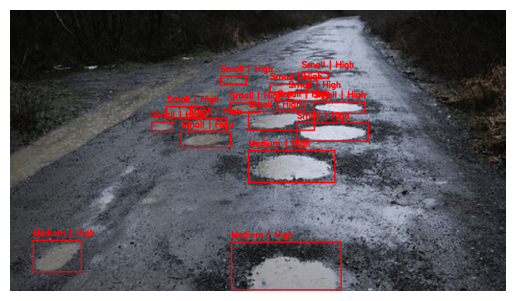

In [ ]:
import cv2
import torch
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

!pip install ultralytics # Ensure ultralytics is installed
from ultralytics import YOLO # Import YOLO

# Load the YOLO model
model = YOLO("/content/runs/detect/train/weights/best.pt")
# Load MiDaS
midas = torch.hub.load("intel-isl/MiDaS", "MiDaS_small")
midas.eval()

midas_transforms = torch.hub.load("intel-isl/MiDaS", "transforms")
transform = midas_transforms.small_transform

# Read image using Pillow for .webp support
img_pil = Image.open(img_path)
# Convert to RGB if not already
if img_pil.mode != 'RGB':
    img_pil = img_pil.convert('RGB')
img = np.array(img_pil)
# OpenCV expects BGR, so convert from RGB
img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# YOLO detection
results = model(img)[0]

# Depth
input_batch = transform(img_rgb)

with torch.no_grad():
    prediction = midas(input_batch)
    prediction = torch.nn.functional.interpolate(
        prediction.unsqueeze(1),
        size=img_rgb.shape[:2],
        mode="bicubic",
        align_corners=False,
    ).squeeze()

depth_map = prediction.cpu().numpy()

# Functions
def classify_size(area, img_area):
    ratio = area / img_area
    if ratio < 0.01:
        return "Small"
    elif ratio < 0.05:
        return "Medium"
    else:
        return "Large"

def classify_severity(depth):
    if depth < 50:
        return "Low"
    elif depth < 150:
        return "Medium"
    else:
        return "High"

h, w, _ = img.shape

# Draw results
for box in results.boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0])

    area = (x2-x1)*(y2-y1)
    size_label = classify_size(area, h*w)

    pothole_depth = depth_map[y1:y2, x1:x2].mean()
    severity = classify_severity(pothole_depth)

    label = f"{size_label} | {severity}"

    cv2.rectangle(img, (x1,y1), (x2,y2), (0,0,255), 2)
    cv2.putText(img, label, (x1,y1-10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,255), 2)

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")

In [ ]:
import os

directory_path = "/content/runs/detect/train/weights/"
if os.path.exists(directory_path):
    print(f"The directory '{directory_path}' exists.")
else:
    print(f"The directory '{directory_path}' does not exist.")

The directory '/content/runs/detect/train/weights/' exists.


In [ ]:
from ultralytics import YOLO

model = YOLO("/content/runs/detect/train/weights/best.pt")

metrics = model.val()

print(metrics)
print("mAP@50:", metrics.box.map50)
print("mAP@50-95:", metrics.box.map)
print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)

Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 93 layers, 25,840,339 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3498.6±654.8 MB/s, size: 654.7 KB)
val: Scanning /content/dataset/val/labels.cache... 133 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 133/133 50.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 9/9 1.4it/s 6.7s
                   all        133        331      0.823      0.734      0.804      0.543
Speed: 4.4ms preprocess, 24.1ms inference, 0.0ms loss, 3.6ms postprocess per image
Results saved to /content/runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b6883df3c80>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precisi